# Hotel Booking Cancellation Prediction
## Comparing Decision Tree, Ensemble and XG Boosting MOdels for Cancellation Risk and Revenue

We analyzed the cancellation risk associated every booking at the time of booking and forcast the cancellation risk associated with the booking, and estimated the expected revenue to be loss if the booking is realized as a means for hotels to identify high risk and high revenue bookings and internally decide how to prioritize them.

We use tree based models and ensemble models famously knowned for capturing complex relationship like the hotel entity and patterns that a logisitc regression can't. A goal is increase the correctness of the model in detecting a booking will be canceled. 

## Load Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sckit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# models(decision trees, random forest, gradient boosting)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Load Data

In [2]:
# load data
hotel_bookings = pd.read_csv('/Users/kiepeeh1/Documents/00 Working Projects/Hotel Data Analytics/Hotel Analytics/Data/Processed_Data/final_hotel_bookings.csv')

# Features Engineering
- convert the target variable (Booking Cancellation Status) to a categorical variable.
- Ensure all categorical variables are classified correctly. 

In [3]:
hotel_bookings['is_canceled'] = hotel_bookings['is_canceled'].astype('category') 
   
# convert all Dtype == 'object' columns to categorical type
for col in hotel_bookings.select_dtypes(include='object').columns:
    hotel_bookings[col] = hotel_bookings[col].astype('category')

### Features Selection

In [4]:
# split the data into features and target variable
feature_cols = [
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number', 'adults'
]

X = pd.get_dummies(hotel_bookings[feature_cols], drop_first=False)
y = hotel_bookings['is_canceled']

### Train/Test Split

In [5]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=19)
print(f"Training set size: {round(len(X_train)/len(X)*100)}% \n\
Testing set size: {round(len(X_test)/len(X)*100)}%")

Training set size: 70% 
Testing set size: 30%


## Model Building
- Set up model specification
- Fit `training data` using the model spec
- Run predictions on `testing data`

In [6]:
# Build models
decision_tree = DecisionTreeClassifier(random_state=19)

# fit the model
decision_tree.fit(X_train, y_train)

# predictions
y_pred_dt = decision_tree.predict(X_test)

## Model Results
- Report model roc_auc score, recall, and precision score
- Report Confusion Matrix
- Plot roc_auc curve 
- Analyze importance `features` or `variables` from the model results

In [7]:
# Classification report
print("Decision Tree Classifier Results:")
target_names = ['Not Canceled', 'Canceled']
print(classification_report(y_test, y_pred_dt, target_names=target_names))

# Confusion Matrix
print("Decision Tree Classifier Confusion Matrix:")
cnf_matrix_df = pd.DataFrame(confusion_matrix(y_test, y_pred_dt), index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])
cnf_matrix_df

Decision Tree Classifier Results:
              precision    recall  f1-score   support

Not Canceled       0.79      0.79      0.79     19011
    Canceled       0.45      0.46      0.46      7208

    accuracy                           0.70     26219
   macro avg       0.62      0.62      0.62     26219
weighted avg       0.70      0.70      0.70     26219

Decision Tree Classifier Confusion Matrix:


,Predicted Not Canceled,Predicted Canceled
Not Canceled,15035,3976
Canceled,3900,3308


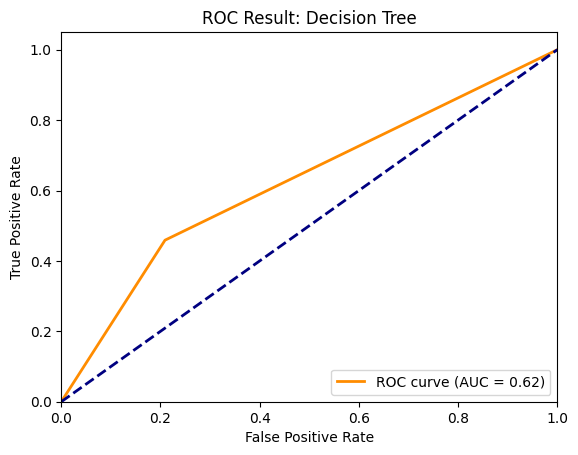

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_pred_dt)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Result: Decision Tree')
plt.legend(loc="lower right")
plt.show()

In [9]:
# decision tree feature importance
feature_importance_dt = pd.DataFrame({
    'feature': X_test.columns,
    'importance': decision_tree.feature_importances_
}).sort_values(by='importance', ascending=False) 

print("Top 10 Features by Importance (Decision Tree)")
display(feature_importance_dt.head(10))

print("Least 10 Features by Importance (Decision Tree)")
display(feature_importance_dt.nsmallest(10, 'importance').copy())

Top 10 Features by Importance (Decision Tree)


,feature,importance
0,lead_time,0.288801
3,adr,0.226962
4,arrival_date_week_number,0.128766
1,stays_in_week_nights,0.089820
2,stays_in_weekend_nights,0.054314
12,market_segment_Online TA,0.040953
26,deposit_type_Non Refund,0.034646
5,adults,0.028693
22,customer_type_Transient-Party,0.014426
24,hotel_Resort Hotel,0.010922


Least 10 Features by Importance (Decision Tree)


,feature,importance
13,market_segment_Undefined,0.000000
27,deposit_type_Refundable,0.000118
18,distribution_channel_Undefined,0.000136
7,market_segment_Complementary,0.000206
16,distribution_channel_GDS,0.000346
25,deposit_type_No Deposit,0.000423
6,market_segment_Aviation,0.000592
20,customer_type_Group,0.000879
8,market_segment_Corporate,0.000998
10,market_segment_Groups,0.001269


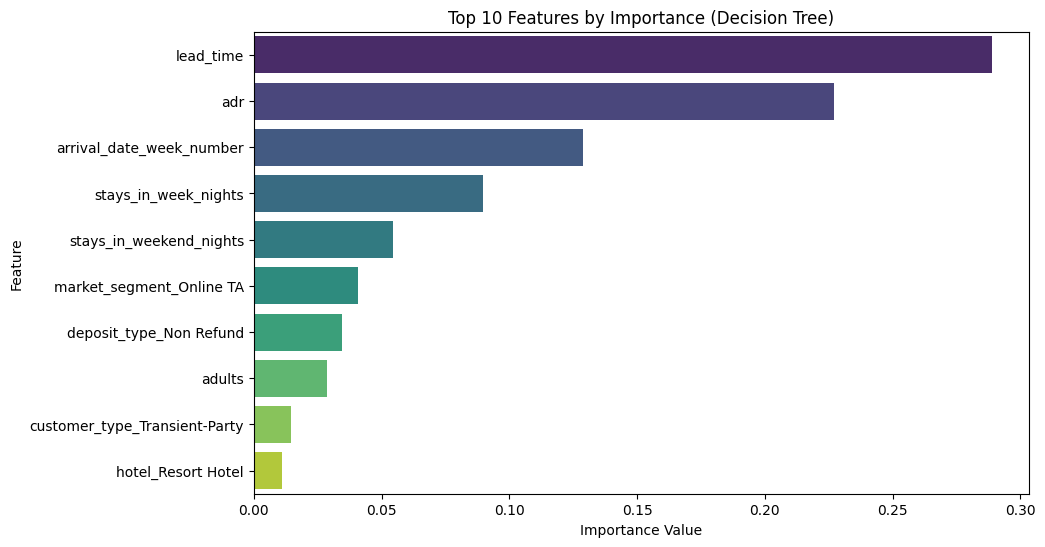

In [10]:
# plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_dt.head(10), hue='feature', palette='viridis')
plt.title('Top 10 Features by Importance (Decision Tree)')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.show()

## Results Summary

So we can notice that the decision tree is performing better so far in predicting cancellation coreectly. 

## Extracting Predictions' Probabilties

In [11]:
# Decision tree probabilities + prediction df
dt_proba = pd.DataFrame(
    decision_tree.predict_proba(X_test),
    columns=['dt_pred_0', 'dt_pred_1'],
    index=X_test.index
)

prediction_dt = X_test.copy()
prediction_dt['actual'] = y_test
prediction_dt['predicted'] = y_pred_dt
prediction_dt = prediction_dt.join(dt_proba)

In [12]:
# random sample 
prediction_dt

,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,arrival_date_week_number,adults,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,...,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,actual,predicted,dt_pred_0,dt_pred_1
80726,1,1,0,110.50,19,1,False,False,False,False,...,False,False,True,False,False,False,0,0,1.0,0.0
79399,143,1,1,89.10,15,2,False,False,False,False,...,False,False,False,False,False,False,0,0,1.0,0.0
36414,204,2,2,72.75,41,2,False,False,False,False,...,False,False,False,False,True,False,0,0,1.0,0.0
76834,2,1,0,143.00,9,2,False,False,False,True,...,False,True,False,False,False,False,0,0,1.0,0.0
79613,54,4,2,111.00,15,2,False,False,False,True,...,False,False,False,False,False,False,0,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22757,101,3,0,197.67,36,2,False,False,False,True,...,False,False,False,False,False,False,0,0,1.0,0.0
60398,86,2,2,80.75,15,2,False,False,False,False,...,False,False,False,False,False,False,0,0,1.0,0.0
83840,167,2,0,112.05,26,2,False,False,False,False,...,True,False,False,False,False,False,0,0,1.0,0.0
42628,9,1,0,130.00,34,2,False,False,False,False,...,False,False,False,False,False,False,1,0,1.0,0.0


# Random Forest and XG Boosting
We are moving beyond the single decision tree baseline to compare the stronger ensemble models on the same cancellation task. The next step focuses on:

- Setting up a tuning process
- Selecting the best hyperparameters with cross-validation
- Evaluating performance on the held-out test set.


In [13]:
import joblib

N_CORES = joblib.cpu_count(only_physical_cores=True) -1
print(f"Number of physical CPU cores: {N_CORES}")

Number of physical CPU cores: 13


## Model Tunning and Validation
This block trains the Random Forest and XGBoost models using tuned hyperparameters and evaluates them with ROC-AUC, accuracy, precision, recall, and F1-score. The goal is to identify which model generalizes best while still balancing predictive performance and class imbalance.

In [ ]:
import warnings
from sklearn.metrics import precision_recall_fscore_support
warnings.filterwarnings("ignore")

# Model Specification
models = {
    'Random Forest': RandomForestClassifier(random_state=19),
    'XGBoost': XGBClassifier(random_state=19, eval_metric='logloss')
}

# Hyperparameter Tunning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 250, 350],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'n_estimators': [100, 150, 250, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

# Use CV for model training
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=19)

# Apply GridSearchCV for best model selection and return the model with best parameter
results = []
for model_name, model in models.items():
    print(f"Training {model_name}...")
    grid_search = GridSearchCV(
        model,
        param_grids[model_name],
        cv=cv,
        scoring='roc_auc',
        n_jobs=N_CORES,
        refit=True,
        error_score='raise'
    )
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary'
    )
    
    results.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Best CV ROC AUC': grid_search.best_score_,
        'Test ROC AUC': roc_auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

Training Random Forest...


NameError: name 'precision_recall_fscore_support' is not defined

## Tunning Results

In [ ]:
print("Model Tuning Results:")
results_df = pd.DataFrame(results)
print(results_df)

Model Tuning Results:
           Model                                    Best Parameters  \
0  Random Forest  {'max_depth': 20, 'min_samples_leaf': 2, 'min_...   
1        XGBoost  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...   

   Best CV ROC AUC  Test ROC AUC  Accuracy  Precision    Recall        F1  
0         0.768870      0.778719  0.758877   0.675794  0.236265  0.350123  
1         0.763233      0.773586  0.757237   0.645596  0.259295  0.369989  


Best model after optimization is `XGClassifier` of 150 n_estimators and 0.1 `learning_rate`.

## Best-Model Results
- Report model roc_auc score, recall, and precision score
- Report Confusion Matrix
- Plot roc_auc curve 
- Analyze `features` or `variables` importance from the model results

In [ ]:
print("XG Boost Best-Model Results")
print(classification_report(y_test, y_pred, target_names=target_names))
# confusion matrix
print("XG Boost Confusion Matrix")
cnf_matrix_xgb_df = pd.DataFrame(confusion_matrix(y_test, y_pred), index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])
cnf_matrix_xgb_df

XG Boost Best-Model Results
              precision    recall  f1-score   support

Not Canceled       0.77      0.95      0.85     19011
    Canceled       0.65      0.26      0.37      7208

    accuracy                           0.76     26219
   macro avg       0.71      0.60      0.61     26219
weighted avg       0.74      0.76      0.72     26219

XG Boost Confusion Matrix


,Predicted Not Canceled,Predicted Canceled
Not Canceled,17985,1026
Canceled,5339,1869


In [ ]:
# decision tree feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': X_test.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False) 

print("Top 10 Features by Importance (Decision Tree)")
display(feature_importance_xgb.head(10))

print("Least 10 Features by Importance (Decision Tree)")
display(feature_importance_xgb.nsmallest(10, 'importance').copy())

Top 10 Features by Importance (Decision Tree)


,feature,importance
26,deposit_type_Non Refund,0.401918
12,market_segment_Online TA,0.166646
21,customer_type_Transient,0.046916
0,lead_time,0.035006
22,customer_type_Transient-Party,0.031620
19,customer_type_Contract,0.020845
23,hotel_City Hotel,0.019427
33,arrival_date_month_July,0.013457
11,market_segment_Offline TA/TO,0.013270
25,deposit_type_No Deposit,0.012329


Least 10 Features by Importance (Decision Tree)


,feature,importance
27,deposit_type_Refundable,0.000000
13,market_segment_Undefined,0.000000
24,hotel_Resort Hotel,0.000000
18,distribution_channel_Undefined,0.000000
6,market_segment_Aviation,0.006307
35,arrival_date_month_March,0.006609
7,market_segment_Complementary,0.007405
16,distribution_channel_GDS,0.007805
10,market_segment_Groups,0.008140
2,stays_in_weekend_nights,0.008149


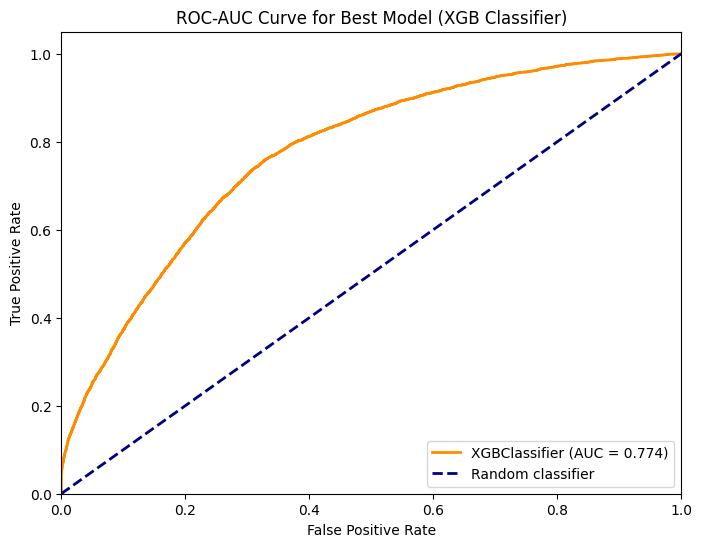

In [ ]:
# ROC-AUC curve for the selected best model
best_model_name = type(best_model).__name__
best_model_proba = best_model.predict_proba(X_test)[:, 1]

fpr_best, tpr_best, _ = roc_curve(y_test, best_model_proba)
roc_auc_best = roc_auc_score(y_test, best_model_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color="darkorange", lw=2,
    label=f"{best_model_name} (AUC = {roc_auc_best:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random classifier")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve for Best Model (XGB Classifier)")
plt.legend(loc="lower right")
#plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Combine test features, actual labels, predictions, and XGBoost probabilities
xgb_proba = pd.DataFrame(
    best_model.predict_proba(X_test),
    columns=["xgb_pred_0", "xgb_pred_1"],
    index=X_test.index
)

prediction_xgb = X_test.copy()
prediction_xgb["actual"] = y_test
prediction_xgb["predicted"] = best_model.predict(X_test)
prediction_xgb = prediction_xgb.join(xgb_proba)

# merge with decision tree 
predictions_combined_2 = prediction_dt.merge(
    prediction_xgb[['xgb_pred_0', 'xgb_pred_1', 'predicted']],
    left_index=True, right_index=True, suffixes=('_dt', '_xgb')
)

predictions_combined_2.head()

,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,arrival_date_week_number,adults,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,...,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,actual,predicted_dt,dt_pred_0,dt_pred_1,xgb_pred_0,xgb_pred_1,predicted_xgb
80726,1,1,0,110.50,19,1,False,False,False,False,...,False,False,False,0,0,1.0,0.0,0.877147,0.122853,0
79399,143,1,1,89.10,15,2,False,False,False,False,...,False,False,False,0,0,1.0,0.0,0.869163,0.130837,0
36414,204,2,2,72.75,41,2,False,False,False,False,...,False,True,False,0,0,1.0,0.0,0.885664,0.114336,0
76834,2,1,0,143.00,9,2,False,False,False,True,...,False,False,False,0,0,1.0,0.0,0.907605,0.092395,0
79613,54,4,2,111.00,15,2,False,False,False,True,...,False,False,False,0,0,1.0,0.0,0.828810,0.171190,0


In [ ]:
# calculate expected revenue per booking: ADR * (stays_in_week_nights + stays_in_weekend_nights)
predictions_combined_2['expected_revenue'] = predictions_combined_2['adr']* (predictions_combined_2['stays_in_week_nights'] + predictions_combined_2['stays_in_weekend_nights'])

# calcuate expected loss per booking for each model: predicted probability of cancellation * expected revenue
predictions_combined_2['dt_Loss'] = predictions_combined_2['dt_pred_1'] * predictions_combined_2['expected_revenue']
predictions_combined_2['xgb_Loss'] = predictions_combined_2['xgb_pred_1'] * predictions_combined_2['expected_revenue']

# calcuate the difference in expected loss between the two models
predictions_combined_2['pred_Loss_diff'] = predictions_combined_2['dt_Loss'] - predictions_combined_2['xgb_Loss']

# summary stats
predictions_combined_2[['actual', 'predicted_dt', 'predicted_xgb', 'dt_pred_1', 'xgb_pred_1', 'expected_revenue', 'xgb_Loss', 'dt_Loss', 'pred_Loss_diff']].head(10)

,actual,predicted_dt,predicted_xgb,dt_pred_1,xgb_pred_1,expected_revenue,xgb_Loss,dt_Loss,pred_Loss_diff
80726,0,0,0,0.0,0.122853,110.50,13.575263,0.00,-13.575263
79399,0,0,0,0.0,0.130837,178.20,23.315112,0.00,-23.315112
36414,0,0,0,0.0,0.114336,291.00,33.271771,0.00,-33.271771
76834,0,0,0,0.0,0.092395,143.00,13.212417,0.00,-13.212417
79613,0,0,0,0.0,0.171190,666.00,114.012486,0.00,-114.012486
59730,0,0,0,0.0,0.479845,619.20,297.119813,0.00,-297.119813
56790,1,1,0,1.0,0.076345,358.68,27.383309,358.68,331.296691
74183,0,1,1,1.0,0.529164,190.74,100.932767,190.74,89.807233
59865,0,0,0,0.0,0.135808,413.12,56.105053,0.00,-56.105053
55709,0,0,0,0.0,0.063860,74.00,4.725616,0.00,-4.725616


>Given the extremely low recall score on this model, we will consider implementing a `scale_pos_weight` in the XGBoost model and `class_weight=balanced` in the Random Forest model to controls the balance of positive and negative weights. Currently, we face a highly imbalance data where there are fewer bookings that were canceled compare to completed bookings. However we would like our model to be strong at predicting those 'canceled' bookings highly. 

>see part II

## Part II: Model Refinement- Adding Imbablance Weight

In [ ]:
warnings.filterwarnings("ignore")

# --- Class imbalance info ---
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos
print(f"Positive: {n_pos}, Negative: {n_neg}, scale_pos_weight: {scale_pos_weight:.2f}")

# --- Models with imbalance handling ---
models = {
    'Random Forest': RandomForestClassifier(random_state=19, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=19, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 250, 350],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'n_estimators': [100, 150, 250, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=19)

results_2 = []
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=cv,
                               scoring='roc_auc', n_jobs=N_CORES,
                               refit=True, error_score='raise')
    grid_search.fit(X_train, y_train)

    best_model_2 = grid_search.best_estimator_

    # Default 0.5 threshold predictions
    y_pred_2 = best_model_2.predict(X_test)
    y_pred_proba_2 = best_model_2.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba_2)
    acc = accuracy_score(y_test, y_pred_2)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_2, average='binary')

    results_2.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Best CV ROC AUC': grid_search.best_score_,
        'Test ROC AUC': roc_auc,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
    })

results_df_2 = pd.DataFrame(results_2)
print("\n=== Model Tuning Results ===")
print(results_df_2.to_string(index=False))

Positive: 16817, Negative: 44360, scale_pos_weight: 2.64

Training Random Forest...

Training XGBoost...

=== Model Tuning Results ===
        Model                                                                       Best Parameters  Best CV ROC AUC  Test ROC AUC  Accuracy  Precision   Recall       F1
Random Forest {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 350}         0.766587      0.776416  0.704985   0.476082 0.727664 0.575583
      XGBoost         {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}         0.763288      0.772898  0.695869   0.466851 0.748335 0.574992


In [ ]:
# classification report for best model
print(classification_report(y_test, y_pred_2, target_names=target_names))

print("XG Boost Confusion Matrix")
cnf_matrix_xgb_df2 = pd.DataFrame(confusion_matrix(y_test, y_pred_2), index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])
cnf_matrix_xgb_df2

              precision    recall  f1-score   support

Not Canceled       0.88      0.68      0.76     19011
    Canceled       0.47      0.75      0.57      7208

    accuracy                           0.70     26219
   macro avg       0.67      0.71      0.67     26219
weighted avg       0.76      0.70      0.71     26219

XG Boost Confusion Matrix


,Predicted Not Canceled,Predicted Canceled
Not Canceled,12851,6160
Canceled,1814,5394


In [ ]:
# Feature Importance
feature_importance_xgb_2 = pd.DataFrame({
    'feature': X_test.columns,
    'importance': best_model_2.feature_importances_
}).sort_values(by = 'importance', ascending=False)

print("Top 10 Features")
print(feature_importance_xgb_2.head(10))

Top 10 Features
                           feature  importance
26         deposit_type_Non Refund    0.299684
12        market_segment_Online TA    0.189828
21         customer_type_Transient    0.045492
0                        lead_time    0.042247
22   customer_type_Transient-Party    0.035735
23                hotel_City Hotel    0.020421
19          customer_type_Contract    0.018821
14  distribution_channel_Corporate    0.014700
11    market_segment_Offline TA/TO    0.014436
25         deposit_type_No Deposit    0.014393


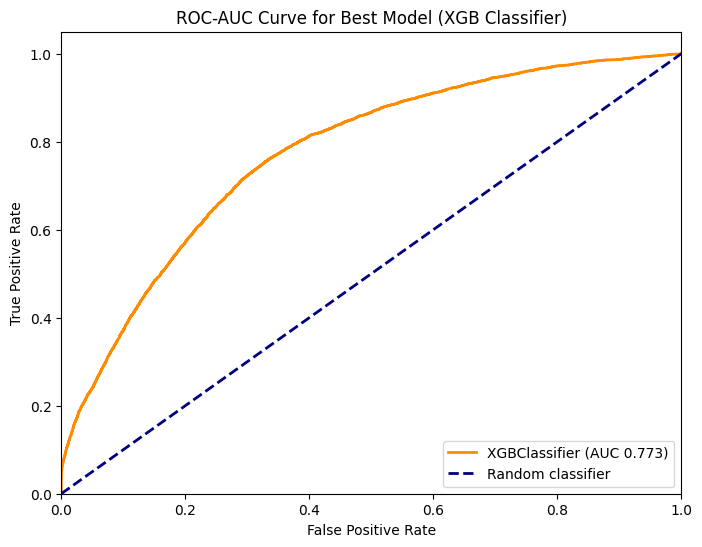

In [ ]:
# ROC AUC
model_name_2 = type(best_model_2).__name__
model_predict_proba = best_model_2.predict_proba(X_test)[:,1]

fpr_best_2, tpr_best_2, _ = roc_curve(y_test, model_predict_proba)
roc_auc_best_2 = roc_auc_score(y_test, model_predict_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_best_2, tpr_best_2, color = 'darkorange', lw=2, 
    label = f"{model_name_2} (AUC {roc_auc_best_2:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve for Best Model (XGB Classifier)")
plt.legend(loc = 4)
plt.show()

# Part II: Feature Refinement and Re-Modeling

We now transition to the second part of the analysis, where the dataset is cleaned and refined before re-running the modeling workflow. The focus here is on reducing noise, improving the feature set, and checking whether the updated modeling frame leads to better cancellation predictions.

### Data Cleaning for Part II

This block removes non-relevant market segments and extreme ADR values that could distort the model. The objective is to create a cleaner modeling dataset that better reflects realistic booking behavior.

In [ ]:
# drop market segment == 'complementary' from the dataset
hotel_bookings_copy2 = hotel_bookings[hotel_bookings['market_segment'] != 'Complementary']
# Drop bookings greater than 1000 in data-- turns out only 1 booking has adr > 1000 (actual 5400), so we can drop it to avoid skewing the data
hotel_bookings_copy2 = hotel_bookings_copy2[hotel_bookings_copy2['adr'] < 1000] 
# drop adr < 0
hotel_bookings_copy2 = hotel_bookings_copy2[hotel_bookings_copy2['adr'] >= 0]

### Revised Feature Engineering

A new set of features is selected to capture booking context, guest pattern, and business risk more directly. These engineered variables are then converted into model-ready form through one-hot encoding for the tree-based learners.

In [ ]:
hotel_bookings_copy2['family_flag'] = hotel_bookings['family_flag'].astype('category') 

New_Features_Cols = ['total_of_special_requests', 'adults', 'family_flag',
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number'
]

new_num_cols = ['total_of_special_requests', 'adults', 'lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'arrival_date_week_number']
new_cat_cols = [c for c in New_Features_Cols if c not in new_num_cols]

#X_new = hotel_bookings_copy2[New_Features_Cols]
X_new = pd.get_dummies(hotel_bookings_copy2[New_Features_Cols], drop_first=False)
y_new = hotel_bookings_copy2['is_canceled']

### Train/Test Split II

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y_new,
    test_size=0.3,
    stratify=y_new,
    random_state=19
)

### Final Model Training on the Refined Dataset

This stage re-trains the ensemble models using the updated feature set and the same hyperparameter tuning approach. The goal is to determine whether the improved data preparation and feature design strengthen the model’s predictive power.

In [ ]:
warnings.filterwarnings("ignore")

# Report class imbalance
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos
print(f"Positive: {n_pos}, Negative: {n_neg}, scale_pos_weight: {scale_pos_weight:.2f}")

# Modify model to handle imbalance classes
models = {
    'Random Forest': RandomForestClassifier(random_state=19, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=19, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 250, 350],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'n_estimators': [100, 150, 250, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=19)

results = []
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=cv,
                               scoring='roc_auc', n_jobs=N_CORES,
                               refit=True, error_score='raise')
    grid_search.fit(X_train, y_train)

    best_model_3 = grid_search.best_estimator_

    # Default 0.5 threshold predictions
    y_pred = best_model_3.predict(X_test)
    y_pred_proba = best_model_3.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary')

    results.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Best CV ROC AUC': grid_search.best_score_,
        'Test ROC AUC': roc_auc,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
    })

results_df_3 = pd.DataFrame(results)
print("\n=== Model Tuning Results ===")
print(results_df_3.to_string(index=False))

Positive: 16755, Negative: 43929, scale_pos_weight: 2.62

Training Random Forest...

Training XGBoost...

=== Model Tuning Results ===
        Model                                                                         Best Parameters  Best CV ROC AUC  Test ROC AUC  Accuracy  Precision   Recall       F1
Random Forest {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 350}         0.810185      0.810432  0.781144   0.606130 0.592118 0.599042
      XGBoost           {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 250, 'subsample': 0.8}         0.806695      0.807703  0.753114   0.541295 0.693636 0.608069


## Final Performance Summary

The final tuning results compare the Random Forest and XGBoost models on the refined dataset. This summary tells us whether the updated modeling setup improves both predictive accuracy and cancellation detection quality.

In [ ]:
cnf_matrix_xgb_3_df = pd.DataFrame(confusion_matrix(y_test, y_pred), index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_names))
print("Confusion Matrix")
print(cnf_matrix_xgb_3_df)

Classification Report
              precision    recall  f1-score   support

Not Canceled       0.87      0.78      0.82     18827
    Canceled       0.54      0.69      0.61      7181

    accuracy                           0.75     26008
   macro avg       0.71      0.73      0.71     26008
weighted avg       0.78      0.75      0.76     26008

Confusion Matrix
              Predicted Not Canceled  Predicted Canceled
Not Canceled                   14606                4221
Canceled                        2200                4981


In [ ]:
# Feature Importance
feature_importance_xgb_3 = pd.DataFrame({
    'feature': X_test.columns,
    'importance': best_model_3.feature_importances_
}).sort_values(by = 'importance', ascending=False)

print("Top 10 Features")
print(feature_importance_xgb_3.head(10))

Top 10 Features
                          feature  importance
29        deposit_type_Non Refund    0.407012
15       market_segment_Online TA    0.108742
0       total_of_special_requests    0.045581
25  customer_type_Transient-Party    0.029642
24        customer_type_Transient    0.023342
2                       lead_time    0.022960
28        deposit_type_No Deposit    0.018150
26               hotel_City Hotel    0.016605
20     distribution_channel_TA/TO    0.014761
14   market_segment_Offline TA/TO    0.014405


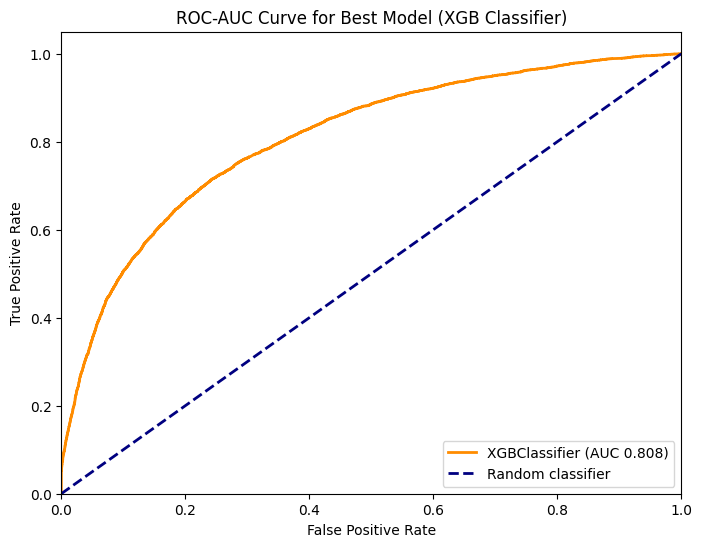

In [171]:
# ROC AUC
model_name_3 = type(best_model_3).__name__
model_predict_proba = best_model_3.predict_proba(X_test)[:,1]

fpr_best_3, tpr_best_3, _ = roc_curve(y_test, model_predict_proba)
roc_auc_best_3 = roc_auc_score(y_test, model_predict_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_best_3, tpr_best_3, color = 'darkorange', lw=2, 
    label = f"{model_name_2} (AUC {roc_auc_best_3:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve for Best Model (XGB Classifier)")
plt.legend(loc = 4)
plt.show()

# Final Findings